Confusion Matrix - Model Validation v2

Applying metrics according to Hafner et al.  (2023) and Corley et al.  (2024)

Based on:
- Hafner, S., Ban, Y., & Nascetti, A. (2023). Semi-Supervised Urban Change Detection Using Multi-Modal Sentinel-1 SAR and Sentinel-2 MSI Data. Remote Sensing, 15(21), 5135.
- Corley, I., Robinson, C., & Ortiz, A. (2024). A Change Detection Reality Check.

## STARTUP

In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [2]:
folder = '/content/drive/MyDrive/Framework/Change_Detection_Validation/urban_cd_app/'

In [3]:
!pip install rasterio geopandas geemap localtileserver -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.7/33.7 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.5/287.5 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.3/204.3 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 82.4 MB/s eta 0:00:00


In [4]:
# Importar bibliotecas
import ee
import geemap
import geopandas as gpd
import rasterio
from rasterio.plot import show
from rasterio.warp import reproject, Resampling
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score

In [5]:
# Autenticar e inicializar o Earth Engine
try:
    ee.Initialize(project="ee-joaovictornh01") # enter the ID of your GEE project
    print("✓ Earth Engine já autenticado")
except:
    print("Autenticando Earth Engine...")
    ee.Authenticate()
    ee.Initialize(project="ee-joaovictornh01") # enter the ID of your GEE project
    print("✓ Earth Engine autenticado com sucesso")

Autenticando Earth Engine...
✓ Earth Engine autenticado com sucesso


# FUNCTIONS

In [6]:
def read_tif(filepath):
    """
    Reads a GeoTIFF file and returns the image data, transform, and CRS.

    Args:
        filepath (str): The path to the GeoTIFF file.

    Returns:
        tuple: A tuple containing:
            - img (numpy.ndarray): The image data as a NumPy array.
            - transform (affine.Affine): The affine transform of the image.
            - crs (rasterio.crs.CRS): The Coordinate Reference System of the image.
    """
    with rasterio.open(filepath) as src:
        img = src.read().transpose(1, 2, 0)  # Rearrange dimensions to (height, width, channels)
        transform = src.transform
        crs = src.crs
    return img, transform, crs

def calculate_change_detection_metrics(y_true, y_pred, threshold=50, verbose=True):
    """
    Calcula métricas de avaliação para Change Detection seguindo as práticas
    recomendadas por Hafner et al. (2023) e Corley et al. (2024).

    Métricas calculadas:
    - F1 Score: Média harmônica de Precision e Recall
    - Precision: TP / (TP + FP) - Proporção de mudanças preditas que são corretas
    - Recall: TP / (TP + FN) - Proporção de mudanças reais que foram detectadas
    - IoU (Intersection over Union): TP / (TP + FP + FN) - Jaccard Index
    - Kappa Score: Concordância entre predição e ground truth
    - Overall Accuracy: (TP + TN) / (TP + TN + FP + FN)

    Args:
        y_true (array): Ground truth (0 = sem mudança, 1 = mudança)
        y_pred (array): Predições do modelo (valores de 0 a 100 representando confiança)
        threshold (int): Limiar para binarizar a predição (0-100)
        verbose (bool): Se True, imprime resultados detalhados

    Returns:
        dict: Dicionário com todas as métricas calculadas
    """
    # Flatten para 1D
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()

    # Remapear ground truth para binário (0 = sem mudança, 1 = mudança)
    y_true_binary = np.where(y_true_flat > 0, 1, 0)

    # Binarizar predição usando o threshold
    y_pred_binary = np.where(y_pred_flat >= threshold, 1, 0)

    # Calcular matriz de confusão
    # Formato: [[TN, FP],
    #           [FN, TP]]
    cm = confusion_matrix(y_true_binary, y_pred_binary)

    # Extrair valores da matriz de confusão
    TN = cm[0, 0]  # True Negatives
    FP = cm[0, 1]  # False Positives
    FN = cm[1, 0]  # False Negatives
    TP = cm[1, 1]  # True Positives

    # Calcular métricas principais (seguindo Hafner et al., 2023 e Corley et al., 2024)

    # Precision (Positive Predictive Value)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0

    # Recall (Sensitivity, True Positive Rate)
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0

    # F1 Score (Harmonic Mean of Precision and Recall)
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

    # IoU (Intersection over Union / Jaccard Index)
    # Métrica principal usada em Hafner et al. (2023)
    iou = TP / (TP + FP + FN) if (TP + FP + FN) > 0 else 0.0

    # Overall Accuracy
    overall_accuracy = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0.0

    # Kappa Score
    kappa = cohen_kappa_score(y_true_binary, y_pred_binary)

    # Armazenar métricas em dicionário
    metrics = {
        'F1': f1,
        'Precision': precision,
        'Recall': recall,
        'IoU': iou,
        'Overall_Accuracy': overall_accuracy,
        'Kappa': kappa,
        'TP': TP,
        'TN': TN,
        'FP': FP,
        'FN': FN,
        'Threshold': threshold
    }

    if verbose:
        print("=" * 70)
        print("MÉTRICAS DE AVALIAÇÃO PARA CHANGE DETECTION")
        print("Baseado em Hafner et al. (2023) e Corley et al. (2024)")
        print("=" * 70)
        print(f"\nThreshold de decisão: {threshold}")
        print("\n--- MATRIZ DE CONFUSÃO ---")
        print(f"                 Predito Negativo  Predito Positivo")
        print(f"Real Negativo         {TN:6d}            {FP:6d}")
        print(f"Real Positivo         {FN:6d}            {TP:6d}")

        print("\n--- MÉTRICAS PRINCIPAIS (Seguindo literatura de Change Detection) ---")
        print(f"F1 Score:           {f1:.4f}  (Média harmônica de Precision e Recall)")
        print(f"Precision:          {precision:.4f}  (TP / (TP + FP))")
        print(f"Recall:             {recall:.4f}  (TP / (TP + FN))")
        print(f"IoU (Jaccard):      {iou:.4f}  (TP / (TP + FP + FN))")

        print("\n--- MÉTRICAS COMPLEMENTARES ---")
        print(f"Overall Accuracy:   {overall_accuracy:.4f}")
        print(f"Kappa Score:        {kappa:.4f}")

        # Interpretação do Kappa (mantida do código original)
        if kappa < 0:
            interpretacao = "Pior que aleatório"
        elif kappa < 0.2:
            interpretacao = "Muito fraco"
        elif kappa < 0.4:
            interpretacao = "Fraco"
        elif kappa < 0.6:
            interpretacao = "Moderado"
        elif kappa < 0.8:
            interpretacao = "Bom"
        else:
            interpretacao = "Excelente"
        print(f"Interpretação Kappa: {interpretacao}")

        # Interpretação do IoU (adicionada conforme Hafner et al., 2023)
        if iou < 0.2:
            interpretacao_iou = "Muito fraco"
        elif iou < 0.4:
            interpretacao_iou = "Fraco"
        elif iou < 0.6:
            interpretacao_iou = "Moderado"
        elif iou < 0.8:
            interpretacao_iou = "Bom"
        else:
            interpretacao_iou = "Excelente"
        print(f"Interpretação IoU:   {interpretacao_iou}")

        print("\n--- RELATÓRIO DE CLASSIFICAÇÃO (scikit-learn) ---")
        print(classification_report(y_true_binary, y_pred_binary,
                                   target_names=["Sem Mudança", "Mudança"],
                                   digits=4))
        print("=" * 70)

    return metrics

def analyze_threshold_sensitivity(y_true, y_pred, thresholds=None):
    """
    Analisa a sensibilidade das métricas a diferentes thresholds.
    Útil para encontrar o threshold ótimo para o seu modelo.

    Args:
        y_true (array): Ground truth
        y_pred (array): Predições do modelo
        thresholds (list): Lista de thresholds para testar.
                          Se None, usa range(0, 101, 5)

    Returns:
        dict: Dicionário com métricas para cada threshold
    """
    if thresholds is None:
        thresholds = list(range(0, 101, 5))

    results = {
        'thresholds': thresholds,
        'f1_scores': [],
        'precisions': [],
        'recalls': [],
        'ious': []
    }

    print("\n" + "=" * 70)
    print("ANÁLISE DE SENSIBILIDADE AO THRESHOLD")
    print("=" * 70)
    print(f"{'Threshold':>10} {'F1':>10} {'Precision':>10} {'Recall':>10} {'IoU':>10}")
    print("-" * 70)

    for threshold in thresholds:
        metrics = calculate_change_detection_metrics(y_true, y_pred,
                                                     threshold=threshold,
                                                     verbose=False)
        results['f1_scores'].append(metrics['F1'])
        results['precisions'].append(metrics['Precision'])
        results['recalls'].append(metrics['Recall'])
        results['ious'].append(metrics['IoU'])

        print(f"{threshold:10d} {metrics['F1']:10.4f} {metrics['Precision']:10.4f} "
              f"{metrics['Recall']:10.4f} {metrics['IoU']:10.4f}")

    # Encontrar threshold ótimo para cada métrica
    best_f1_idx = np.argmax(results['f1_scores'])
    best_iou_idx = np.argmax(results['ious'])

    print("-" * 70)
    print(f"\nMelhor F1 Score:  {results['f1_scores'][best_f1_idx]:.4f} "
          f"(threshold = {thresholds[best_f1_idx]})")
    print(f"Melhor IoU:       {results['ious'][best_iou_idx]:.4f} "
          f"(threshold = {thresholds[best_iou_idx]})")
    print("=" * 70)

    return results

def plot_threshold_analysis(results, save_path=None):
    """
    Plota gráficos da análise de sensibilidade ao threshold.

    Args:
        results (dict): Resultado da função analyze_threshold_sensitivity
        save_path (str): Caminho para salvar a figura. Se None, apenas exibe.
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Análise de Sensibilidade ao Threshold de Decisão',
                 fontsize=16, fontweight='bold')

    thresholds = results['thresholds']

    # F1 Score
    axes[0, 0].plot(thresholds, results['f1_scores'],
                    marker='o', linestyle='-', color='blue', linewidth=2)
    axes[0, 0].set_title('F1 Score vs. Threshold', fontweight='bold')
    axes[0, 0].set_xlabel('Threshold de Decisão')
    axes[0, 0].set_ylabel('F1 Score')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].set_ylim(0, 1)
    best_f1_idx = np.argmax(results['f1_scores'])
    axes[0, 0].axvline(x=thresholds[best_f1_idx], color='red',
                       linestyle='--', alpha=0.7,
                       label=f'Melhor: {thresholds[best_f1_idx]}')
    axes[0, 0].legend()

    # IoU
    axes[0, 1].plot(thresholds, results['ious'],
                    marker='o', linestyle='-', color='green', linewidth=2)
    axes[0, 1].set_title('IoU vs. Threshold', fontweight='bold')
    axes[0, 1].set_xlabel('Threshold de Decisão')
    axes[0, 1].set_ylabel('IoU (Intersection over Union)')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_ylim(0, 1)
    best_iou_idx = np.argmax(results['ious'])
    axes[0, 1].axvline(x=thresholds[best_iou_idx], color='red',
                       linestyle='--', alpha=0.7,
                       label=f'Melhor: {thresholds[best_iou_idx]}')
    axes[0, 1].legend()

    # Precision
    axes[1, 0].plot(thresholds, results['precisions'],
                    marker='o', linestyle='-', color='orange', linewidth=2)
    axes[1, 0].set_title('Precision vs. Threshold', fontweight='bold')
    axes[1, 0].set_xlabel('Threshold de Decisão')
    axes[1, 0].set_ylabel('Precision')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_ylim(0, 1)

    # Recall
    axes[1, 1].plot(thresholds, results['recalls'],
                    marker='o', linestyle='-', color='purple', linewidth=2)
    axes[1, 1].set_title('Recall vs. Threshold', fontweight='bold')
    axes[1, 1].set_xlabel('Threshold de Decisão')
    axes[1, 1].set_ylabel('Recall')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].set_ylim(0, 1)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"\nGráfico salvo em: {save_path}")

    plt.show()

In [7]:
def plot_concordance_map(
    ground_truth,
    prediction,
    prediction_name='Predição',
    threshold=50,
    is_binary=False,
    save_path=None,
    figsize=(20, 6),
    show_metrics=True
):
    """
    Plota mapa de concordância entre ground truth e predição.

    Args:
        ground_truth (np.array): Ground truth (valores 0 ou 1)
        prediction (np.array): Predição do modelo ou máscara
        prediction_name (str): Nome da predição para títulos
        threshold (float): Limiar para binarizar predição (se não for binária)
        is_binary (bool): Se True, predição já é binária (0/1)
        save_path (str): Caminho para salvar figura
        figsize (tuple): Tamanho da figura
        show_metrics (bool): Se True, mostra métricas no título

    Returns:
        dict: Dicionário com estatísticas de concordância
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch

    print("\n" + "="*80)
    print(f"MAPA DE CONCORDÂNCIA: {prediction_name} vs Ground Truth")
    print("="*80)

    # Garantir que são arrays 2D
    if len(ground_truth.shape) == 3:
        ground_truth = ground_truth[:, :, 0]
    if len(prediction.shape) == 3:
        prediction = prediction[:, :, 0]

    # Flatten para análise
    gt_flat = ground_truth.flatten()
    pred_flat = prediction.flatten()

    # Binarizar ground truth
    gt_binary = np.where(gt_flat > 0, 1, 0)

    # Binarizar predição
    if is_binary:
        pred_binary = pred_flat.astype(int)
    else:
        pred_binary = np.where(pred_flat >= threshold, 1, 0)

    # Calcular concordância
    TP = np.sum((gt_binary == 1) & (pred_binary == 1))  # True Positives
    TN = np.sum((gt_binary == 0) & (pred_binary == 0))  # True Negatives
    FP = np.sum((gt_binary == 0) & (pred_binary == 1))  # False Positives
    FN = np.sum((gt_binary == 1) & (pred_binary == 0))  # False Negatives

    total_pixels = len(gt_binary)
    concordancia_total = TP + TN

    # Estatísticas
    print(f"\n📊 Estatísticas de Concordância:")
    print(f"   Total de pixels: {total_pixels:,}")
    print(f"\n   ✅ True Positives (TP):  {TP:,} ({TP/total_pixels*100:.2f}%)")
    print(f"   ✅ True Negatives (TN):  {TN:,} ({TN/total_pixels*100:.2f}%)")
    print(f"   ❌ False Positives (FP): {FP:,} ({FP/total_pixels*100:.2f}%)")
    print(f"   ❌ False Negatives (FN): {FN:,} ({FN/total_pixels*100:.2f}%)")
    print(f"\n   📈 Concordância Total:   {concordancia_total:,} ({concordancia_total/total_pixels*100:.2f}%)")

    # Calcular métricas
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    iou = TP / (TP + FP + FN) if (TP + FP + FN) > 0 else 0.0
    accuracy = (TP + TN) / total_pixels

    print(f"\n   📊 Métricas:")
    print(f"      • F1 Score:  {f1:.4f}")
    print(f"      • Precision: {precision:.4f}")
    print(f"      • Recall:    {recall:.4f}")
    print(f"      • IoU:       {iou:.4f}")
    print(f"      • Accuracy:  {accuracy:.4f}")

    # Criar mapa de concordância
    # 0 = TN (branco), 1 = TP (verde), 2 = FP (vermelho), 3 = FN (amarelo)
    concordance_map = np.zeros_like(gt_binary)
    concordance_map[(gt_binary == 0) & (pred_binary == 0)] = 0  # TN
    concordance_map[(gt_binary == 1) & (pred_binary == 1)] = 1  # TP
    concordance_map[(gt_binary == 0) & (pred_binary == 1)] = 2  # FP
    concordance_map[(gt_binary == 1) & (pred_binary == 0)] = 3  # FN

    # Reshape para 2D
    concordance_map_2d = concordance_map.reshape(ground_truth.shape)
    pred_binary_2d = pred_binary.reshape(ground_truth.shape)

    # Criar visualização
    fig, axes = plt.subplots(1, 3, figsize=figsize)

    # 1. Ground Truth
    ax1 = axes[0]
    im1 = ax1.imshow(ground_truth, cmap='Greys_r', vmin=0, vmax=1)
    ax1.set_title('Ground Truth\n(1 = Mudança, 0 = Sem Mudança)',
                  fontsize=12, fontweight='bold')
    ax1.axis('off')
    cbar1 = plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
    cbar1.set_label('Classe', rotation=270, labelpad=15)

    # 2. Predição
    ax2 = axes[1]
    if is_binary:
        im2 = ax2.imshow(pred_binary_2d, cmap='Greys_r', vmin=0, vmax=1)
        ax2.set_title(f'{prediction_name}\n(1 = Mudança, 0 = Sem Mudança)',
                      fontsize=12, fontweight='bold')
    else:
        im2 = ax2.imshow(prediction, cmap='viridis', vmin=0, vmax=100)
        ax2.set_title(f'{prediction_name}\n(Threshold = {threshold})',
                      fontsize=12, fontweight='bold')
    ax2.axis('off')
    cbar2 = plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
    cbar2.set_label('Valor' if not is_binary else 'Classe', rotation=270, labelpad=15)

    # 3. Mapa de Concordância
    ax3 = axes[2]
    colors = ['white', '#00ff00', '#ff0000', '#ffff00']  # TN, TP, FP, FN
    cmap_concordance = plt.matplotlib.colors.ListedColormap(colors)
    im3 = ax3.imshow(concordance_map_2d, cmap=cmap_concordance, vmin=0, vmax=3)
    ax3.set_title('Mapa de Concordância\n(Verde=TP, Vermelho=FP, Amarelo=FN, Branco=TN)',
                  fontsize=12, fontweight='bold')
    ax3.axis('off')

    # Legenda customizada
    legend_elements = [
        Patch(facecolor='white', edgecolor='black', linewidth=2,
              label=f'TN: Ambos sem mudança ({TN:,} - {TN/total_pixels*100:.1f}%)'),
        Patch(facecolor='#00ff00',
              label=f'TP: Ambos com mudança ({TP:,} - {TP/total_pixels*100:.1f}%)'),
        Patch(facecolor='#ff0000',
              label=f'FP: Falso Positivo ({FP:,} - {FP/total_pixels*100:.1f}%)'),
        Patch(facecolor='#ffff00',
              label=f'FN: Falso Negativo ({FN:,} - {FN/total_pixels*100:.1f}%)')
    ]
    ax3.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5),
              fontsize=10, frameon=True, fancybox=True, shadow=True)

    # Título geral
    if show_metrics:
        title = (f'Análise de Concordância: {prediction_name} vs Ground Truth\n'
                f'F1={f1:.4f} | IoU={iou:.4f} | Precision={precision:.4f} | '
                f'Recall={recall:.4f} | Accuracy={accuracy:.4f}')
    else:
        title = f'Análise de Concordância: {prediction_name} vs Ground Truth'

    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.02)

    plt.tight_layout()

    # Salvar figura
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"\n✓ Figura salva em: {save_path}")

    plt.show()

    print("="*80)

    # Retornar estatísticas
    return {
        'TP': int(TP),
        'TN': int(TN),
        'FP': int(FP),
        'FN': int(FN),
        'total_pixels': int(total_pixels),
        'concordancia_total': int(concordancia_total),
        'f1': float(f1),
        'precision': float(precision),
        'recall': float(recall),
        'iou': float(iou),
        'accuracy': float(accuracy),
        'concordancia_map_2d': concordance_map_2d
    }

In [8]:
def enhance_rgb_visualization(rgb_array, scale_factor=10000, pmin=2, pmax=98, gamma=1.3, brightness=0.1):
    """
    Aplica normalização, recorte por percentil, correção gamma e brilho.
    """
    rgb = rgb_array.astype(np.float32) / scale_factor
    p_low = np.nanpercentile(rgb, pmin)
    p_high = np.nanpercentile(rgb, pmax)
    rgb = (rgb - p_low) / (p_high - p_low)
    rgb = np.clip(rgb, 0, 1)

    # Correção gamma e brilho
    rgb = np.power(rgb, 1 / gamma)
    rgb = np.clip(rgb + brightness, 0, 1)

    print(f"  💡 Brilho aplicado (γ={gamma}, Δ={brightness:+.2f}) | "
          f"Intervalo reescalado: {p_low:.4f}-{p_high:.4f}")
    print(f"  📈 Pós-ajuste: min={rgb.min():.3f}, max={rgb.max():.3f}, mean={rgb.mean():.3f}")

    return rgb

# EVALUATION OF THE DEEP LEARNING MODEL - APPLICATION OF METRICS

In [9]:
# Set the file path to the local GeoTIFF of the change prediction
predicted_change_path = f'{folder}pred_Sobral_Belchior.tif'

print(f"\nCarregando arquivo de predição:")
print(f"  {predicted_change_path}")

predicted_change_img, predicted_transform, predicted_crs = read_tif(predicted_change_path)
predicted_change_band = predicted_change_img[:, :, 0]

print(f"✓ Imagem de predição carregada. Shape: {predicted_change_band.shape}")
print(f"  Valores: Min={predicted_change_band.min():.2f}, "
      f"Max={predicted_change_band.max():.2f}, "
      f"Mean={predicted_change_band.mean():.2f}")


Carregando arquivo de predição:
  /content/drive/MyDrive/Framework/Change_Detection_Validation/urban_cd_app/pred_Sobral_Belchior.tif
✓ Imagem de predição carregada. Shape: (288, 284)
  Valores: Min=0.00, Max=99.00, Mean=8.63


In [10]:
# Load Ground Truth
ground_truth_path = f'{folder}ground_truth.tif'
print(f"\nCarregando Ground Truth:")
print(f"  {ground_truth_path}")

ground_truth_img, gt_transform, gt_crs = read_tif(ground_truth_path)
ground_truth_band = ground_truth_img[:, :, 0]

print(f"✓ Ground Truth carregado. Shape original: {ground_truth_band.shape}")
print(f"  CRS: {gt_crs}")


Carregando Ground Truth:
  /content/drive/MyDrive/Framework/Change_Detection_Validation/urban_cd_app/ground_truth.tif
✓ Ground Truth carregado. Shape original: (2480, 2480)
  CRS: EPSG:32724


In [12]:
# Redesign and align Ground Truth with prediction
print("\nReprojetando Ground Truth para alinhar com a predição...")
ground_truth_aligned = np.empty_like(predicted_change_band, dtype=ground_truth_band.dtype)

reproject(
    source=ground_truth_band,
    destination=ground_truth_aligned,
    src_transform=gt_transform,
    src_crs=gt_crs,
    dst_transform=predicted_transform,
    dst_crs=predicted_crs,
    resampling=Resampling.nearest  # nearest is ideal for categorical data
)


print(f"✓ Ground Truth reprojetado. Shape final: {ground_truth_aligned.shape}")

# Aligned data statistics
unique_gt, counts_gt = np.unique(ground_truth_aligned, return_counts=True)
print(f"\nEstatísticas do Ground Truth alinhado:")
for val, count in zip(unique_gt, counts_gt):
    print(f"  Valor {val}: {count} pixels ({100*count/ground_truth_aligned.size:.2f}%)")


Reprojetando Ground Truth para alinhar com a predição...
✓ Ground Truth reprojetado. Shape final: (288, 284)

Estatísticas do Ground Truth alinhado:
  Valor 0: 77696 pixels (94.99%)
  Valor 255: 4096 pixels (5.01%)


In [13]:
# Save redesigned files (for later viewing)
predicted_out = f"{folder}predicted_cropped.tif"
gt_out = f"{folder}ground_truth_cropped.tif"

print(f"\nSalvando arquivos alinhados...")
with rasterio.open(
    predicted_out,
    "w",
    driver="GTiff",
    height=predicted_change_band.shape[0],
    width=predicted_change_band.shape[1],
    count=1,
    dtype=predicted_change_band.dtype,
    crs=predicted_crs,
    transform=predicted_transform,
) as dst:
    dst.write(predicted_change_band, 1)

with rasterio.open(
    gt_out,
    "w",
    driver="GTiff",
    height=ground_truth_aligned.shape[0],
    width=ground_truth_aligned.shape[1],
    count=1,
    dtype=ground_truth_aligned.dtype,
    crs=predicted_crs,
    transform=predicted_transform,
) as dst:
    dst.write(ground_truth_aligned, 1)

print(f"✓ Arquivos salvos:")
print(f"  - {predicted_out}")
print(f"  - {gt_out}")


Salvando arquivos alinhados...
✓ Arquivos salvos:
  - /content/drive/MyDrive/Framework/Change_Detection_Validation/urban_cd_app/predicted_cropped.tif
  - /content/drive/MyDrive/Framework/Change_Detection_Validation/urban_cd_app/ground_truth_cropped.tif


In [14]:
# 1. Assessment with standard threshold (50)
print("\n### AVALIAÇÃO COM THRESHOLD = 50 ###")
metrics_50 = calculate_change_detection_metrics(
    ground_truth_aligned,
    predicted_change_band,
    threshold=50,
    verbose=True
)


### AVALIAÇÃO COM THRESHOLD = 50 ###
MÉTRICAS DE AVALIAÇÃO PARA CHANGE DETECTION
Baseado em Hafner et al. (2023) e Corley et al. (2024)

Threshold de decisão: 50

--- MATRIZ DE CONFUSÃO ---
                 Predito Negativo  Predito Positivo
Real Negativo          74215              3481
Real Positivo           1195              2901

--- MÉTRICAS PRINCIPAIS (Seguindo literatura de Change Detection) ---
F1 Score:           0.5537  (Média harmônica de Precision e Recall)
Precision:          0.4546  (TP / (TP + FP))
Recall:             0.7083  (TP / (TP + FN))
IoU (Jaccard):      0.3829  (TP / (TP + FP + FN))

--- MÉTRICAS COMPLEMENTARES ---
Overall Accuracy:   0.9428
Kappa Score:        0.5247
Interpretação Kappa: Moderado
Interpretação IoU:   Fraco

--- RELATÓRIO DE CLASSIFICAÇÃO (scikit-learn) ---
              precision    recall  f1-score   support

 Sem Mudança     0.9842    0.9552    0.9695     77696
     Mudança     0.4546    0.7083    0.5537      4096

    accuracy             

In [15]:
# 2. Threshold sensitivity analysis
print("\n\n### ANÁLISE DE SENSIBILIDADE AO THRESHOLD ###")
threshold_results = analyze_threshold_sensitivity(
    ground_truth_aligned,
    predicted_change_band,
    thresholds=list(range(0, 101, 5))
)



### ANÁLISE DE SENSIBILIDADE AO THRESHOLD ###

ANÁLISE DE SENSIBILIDADE AO THRESHOLD
 Threshold         F1  Precision     Recall        IoU
----------------------------------------------------------------------
         0     0.0954     0.0501     1.0000     0.0501
         5     0.4078     0.2576     0.9778     0.2561
        10     0.4633     0.3065     0.9492     0.3015
        15     0.4944     0.3372     0.9263     0.3284
        20     0.5137     0.3596     0.8992     0.3457
        25     0.5278     0.3786     0.8713     0.3585
        30     0.5379     0.3945     0.8455     0.3679
        35     0.5470     0.4109     0.8176     0.3764
        40     0.5508     0.4245     0.7842     0.3801
        45     0.5538     0.4400     0.7471     0.3829
        50     0.5537     0.4546     0.7083     0.3829
        55     0.5505     0.4674     0.6697     0.3798
        60     0.5444     0.4807     0.6277     0.3740
        65     0.5363     0.4957     0.5842     0.3664
        70     0.

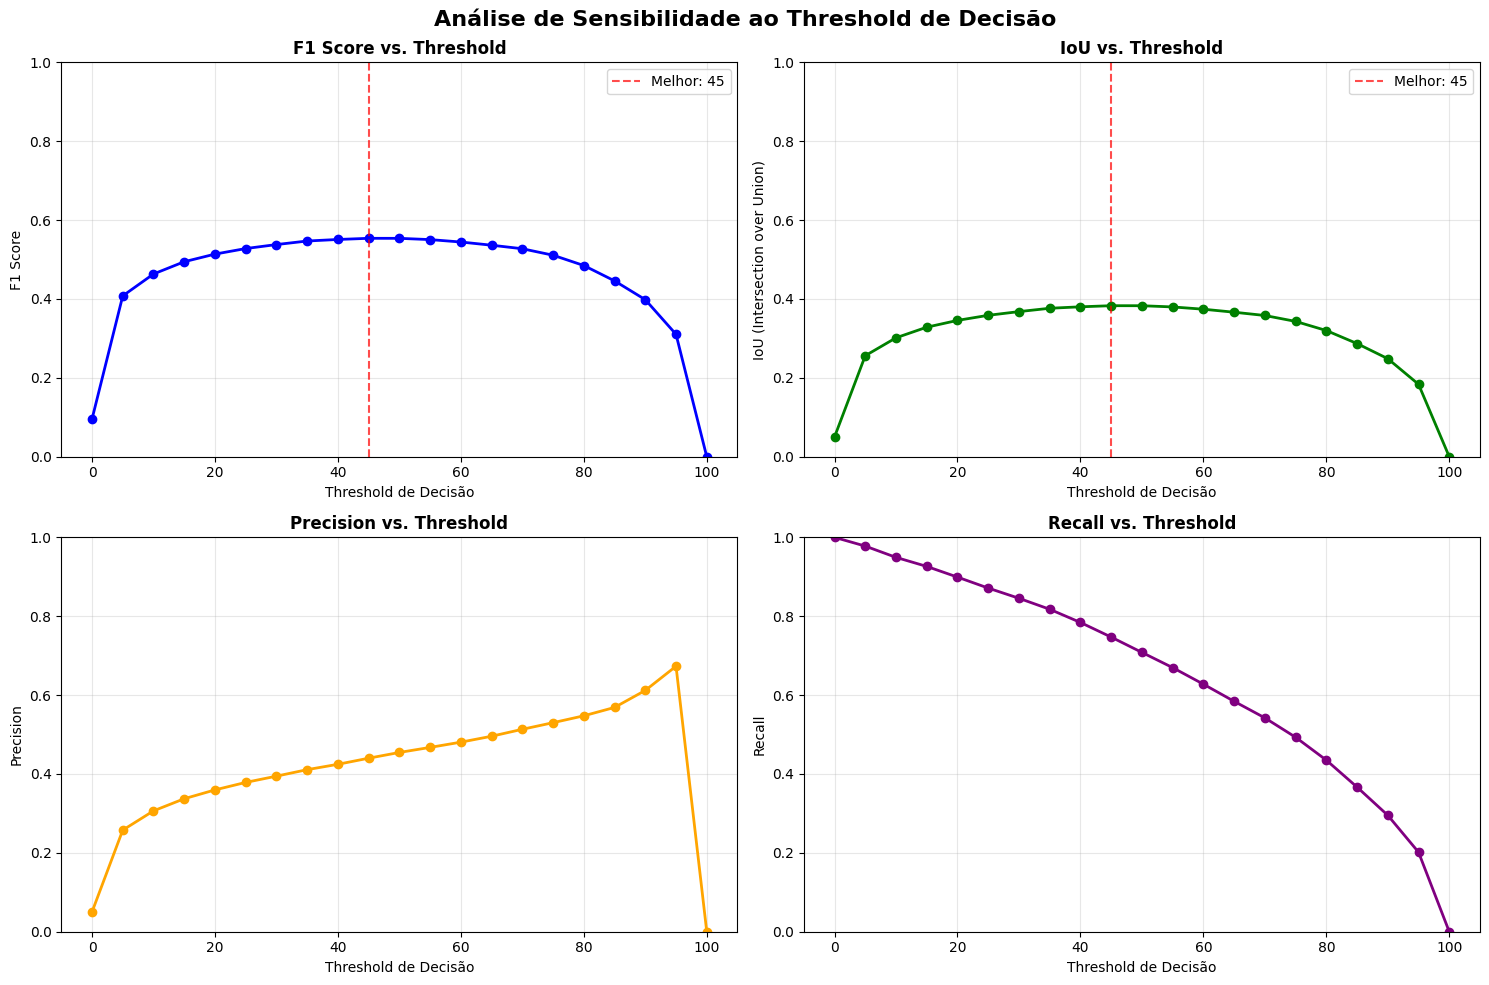

In [16]:
# 3. Plot analysis results
plot_threshold_analysis(
    threshold_results,
    save_path=None #f"{folder}threshold_analysis.png"
)

In [17]:
# 4. Evaluation with optimal threshold (based on F1)
best_f1_threshold = threshold_results['thresholds'][
    np.argmax(threshold_results['f1_scores'])
]
print(f"\nAVALIAÇÃO COM THRESHOLD ÓTIMO (F1) = {best_f1_threshold} ")
metrics_best = calculate_change_detection_metrics(
    ground_truth_aligned,
    predicted_change_band,
    threshold=best_f1_threshold, # You can enter a threshold manually if you want
    verbose=True
)


AVALIAÇÃO COM THRESHOLD ÓTIMO (F1) = 45 
MÉTRICAS DE AVALIAÇÃO PARA CHANGE DETECTION
Baseado em Hafner et al. (2023) e Corley et al. (2024)

Threshold de decisão: 45

--- MATRIZ DE CONFUSÃO ---
                 Predito Negativo  Predito Positivo
Real Negativo          73801              3895
Real Positivo           1036              3060

--- MÉTRICAS PRINCIPAIS (Seguindo literatura de Change Detection) ---
F1 Score:           0.5538  (Média harmônica de Precision e Recall)
Precision:          0.4400  (TP / (TP + FP))
Recall:             0.7471  (TP / (TP + FN))
IoU (Jaccard):      0.3829  (TP / (TP + FP + FN))

--- MÉTRICAS COMPLEMENTARES ---
Overall Accuracy:   0.9397
Kappa Score:        0.5238
Interpretação Kappa: Moderado
Interpretação IoU:   Fraco

--- RELATÓRIO DE CLASSIFICAÇÃO (scikit-learn) ---
              precision    recall  f1-score   support

 Sem Mudança     0.9862    0.9499    0.9677     77696
     Mudança     0.4400    0.7471    0.5538      4096

    accuracy         

In [18]:
# 5. Comparative summary
print("\n" + "=" * 70)
print("RESUMO COMPARATIVO DAS MÉTRICAS")
print("=" * 70)
print(f"\n{'Métrica':<20} {'Threshold=50':<15} {'Threshold Ótimo':<15}")
print("-" * 70)
print(f"{'F1 Score':<20} {metrics_50['F1']:<15.4f} {metrics_best['F1']:<15.4f}")
print(f"{'Precision':<20} {metrics_50['Precision']:<15.4f} {metrics_best['Precision']:<15.4f}")
print(f"{'Recall':<20} {metrics_50['Recall']:<15.4f} {metrics_best['Recall']:<15.4f}")
print(f"{'IoU':<20} {metrics_50['IoU']:<15.4f} {metrics_best['IoU']:<15.4f}")
print(f"{'Kappa':<20} {metrics_50['Kappa']:<15.4f} {metrics_best['Kappa']:<15.4f}")
print("=" * 70)


RESUMO COMPARATIVO DAS MÉTRICAS

Métrica              Threshold=50    Threshold Ótimo
----------------------------------------------------------------------
F1 Score             0.5537          0.5538         
Precision            0.4546          0.4400         
Recall               0.7083          0.7471         
IoU                  0.3829          0.3829         
Kappa                0.5247          0.5238         


## VISUALIZATION


MAPA DE CONCORDÂNCIA: Predição do Modelo vs Ground Truth

📊 Estatísticas de Concordância:
   Total de pixels: 81,792

   ✅ True Positives (TP):  3,060 (3.74%)
   ✅ True Negatives (TN):  73,801 (90.23%)
   ❌ False Positives (FP): 3,895 (4.76%)
   ❌ False Negatives (FN): 1,036 (1.27%)

   📈 Concordância Total:   76,861 (93.97%)

   📊 Métricas:
      • F1 Score:  0.5538
      • Precision: 0.4400
      • Recall:    0.7471
      • IoU:       0.3829
      • Accuracy:  0.9397


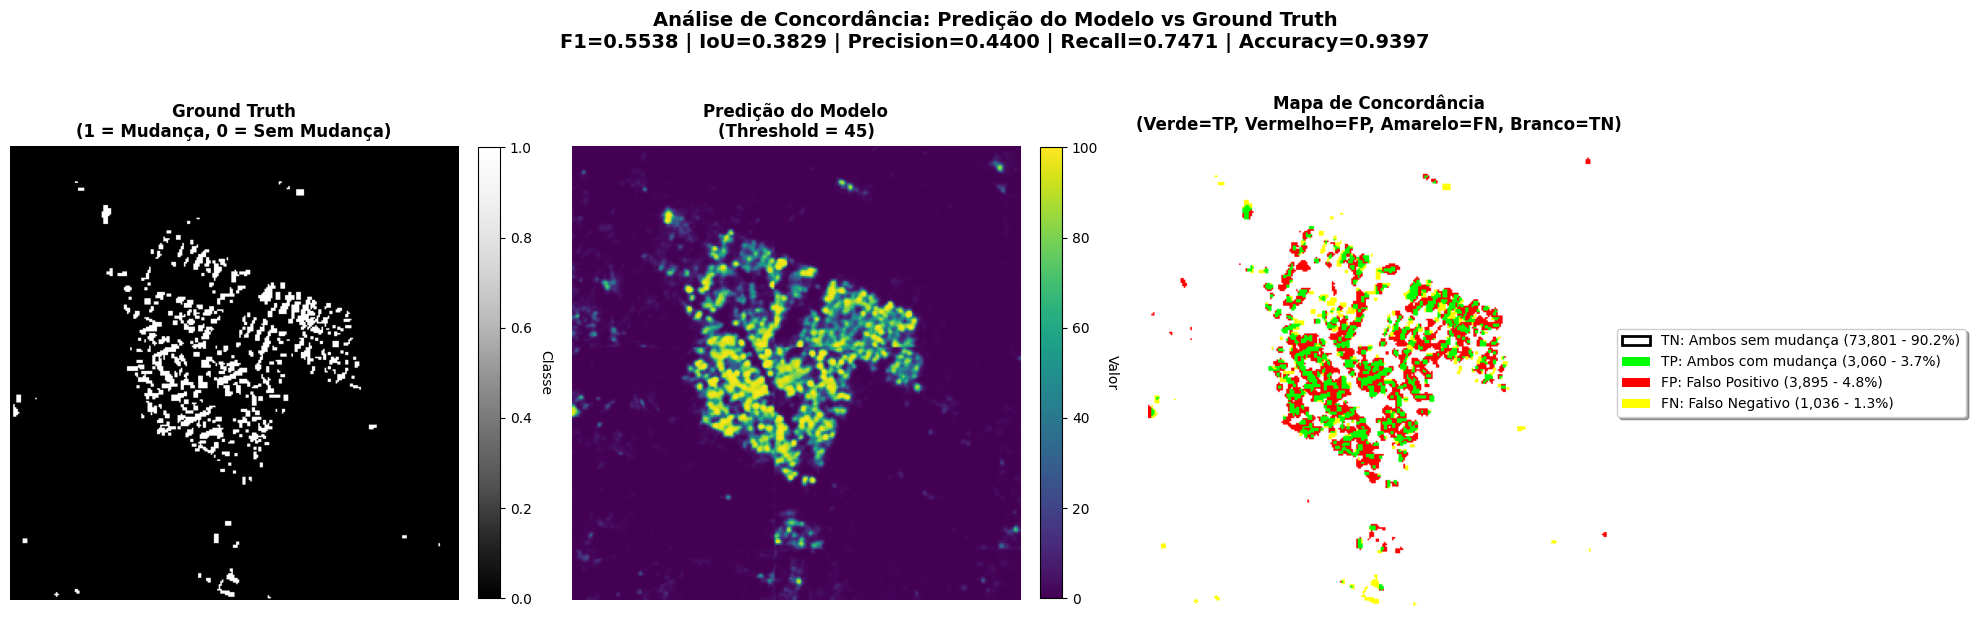

In [19]:
stats_model = plot_concordance_map(
    ground_truth=ground_truth_aligned,
    prediction=predicted_change_band,
    prediction_name='Predição do Modelo',
    threshold=45,
    is_binary=False,
    show_metrics=True,
    save_path= None # f'{folder}concordance_model_vs_gt.png'
)

In [20]:
# Check available files in the folder
from pathlib import Path

folder_path = Path(folder)
assert(folder_path.exists()), f"Pasta não encontrada: {folder}"
print('\nArquivos disponíveis na pasta:')
for f in sorted(folder_path.iterdir()):
    if f.is_file():
        print(f"  - {f.name}")


Arquivos disponíveis na pasta:
  - ground_truth.tif
  - ground_truth_cropped.tif
  - mask_gain_área_construída.tif
  - pred_Sobral_Belchior.tif
  - predicted_cropped.tif
  - sentinel1_Sobral_Belchior_t1.tif
  - sentinel1_Sobral_Belchior_t2.tif
  - sentinel2_Sobral_Belchior_t1.tif
  - sentinel2_Sobral_Belchior_t2.tif


# EVALUATION OF THE NBAI MASK (THRESHOLD-BASED CHANGE DETECTION)

## VISUALIZATION


Carregando máscara NBAI de: /content/drive/MyDrive/Framework/Change_Detection_Validation/urban_cd_app/mask_gain_área_construída.tif
✓ Máscara NBAI carregada com sucesso
  Shape: (288, 284)
  CRS: EPSG:32724
  Valores únicos: [  0 255]
  Dtype: uint8

✓ Máscara convertida para binário (0=sem ganho, 1=ganho)
  Valores únicos após conversão: [0 1]
  Pixels com ganho (1): 7,546
  Pixels sem ganho (0): 74,246
  Percentual de ganho: 9.23%

AVALIAÇÃO: MÁSCARA NBAI vs GROUND TRUTH
MÉTRICAS DE AVALIAÇÃO PARA CHANGE DETECTION
Baseado em Hafner et al. (2023) e Corley et al. (2024)

Threshold de decisão: 50

--- MATRIZ DE CONFUSÃO ---
                 Predito Negativo  Predito Positivo
Real Negativo          71763              5933
Real Positivo           2483              1613

--- MÉTRICAS PRINCIPAIS (Seguindo literatura de Change Detection) ---
F1 Score:           0.2771  (Média harmônica de Precision e Recall)
Precision:          0.2138  (TP / (TP + FP))
Recall:             0.3938  (TP / (TP 

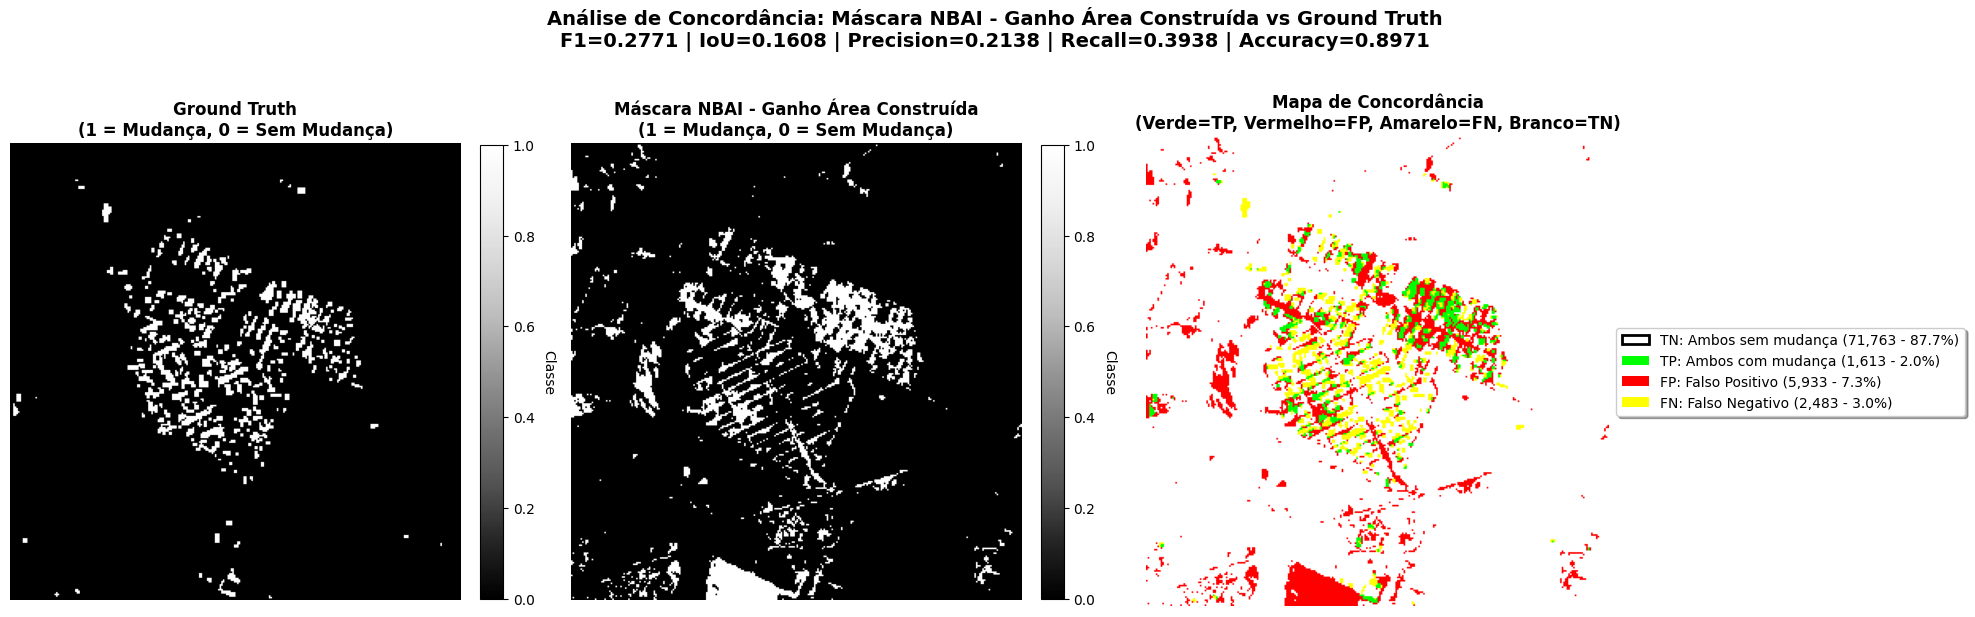


RESUMO FINAL: DESEMPENHO DA MÁSCARA NBAI

Métrica                   Valor           Interpretação                 
--------------------------------------------------------------------------------
F1 Score                  0.2771          Moderado
Precision                 0.2138          21.4% das detecções corretas
Recall                    0.3938          39.4% das mudanças detectadas
IoU (Jaccard)             0.1608          Moderado
Kappa Score               0.2269          Moderado
Overall Accuracy          0.8971          89.7% pixels corretos


In [27]:
# @title
mask_nbai_path = f'{folder}mask_gain_área_construída.tif'

print(f"\nCarregando máscara NBAI de: {mask_nbai_path}")

try:
    # Carregar máscara NBAI
    with rasterio.open(mask_nbai_path) as src:
        mask_nbai = src.read(1)  # Ler primeira banda
        mask_nbai_transform = src.transform
        mask_nbai_crs = src.crs
        mask_nbai_shape = mask_nbai.shape

    print(f"✓ Máscara NBAI carregada com sucesso")
    print(f"  Shape: {mask_nbai_shape}")
    print(f"  CRS: {mask_nbai_crs}")
    print(f"  Valores únicos: {np.unique(mask_nbai)}")
    print(f"  Dtype: {mask_nbai.dtype}")

    # Verificar se precisa reproject para alinhar com ground truth
    if mask_nbai_shape != ground_truth_aligned.shape or mask_nbai_crs != predicted_crs:
        print(f"\n⚠️  Dimensões ou CRS diferentes. Reprojetando máscara NBAI...")
        print(f"  Ground Truth shape: {ground_truth_aligned.shape}, CRS: {predicted_crs}")
        print(f"  Máscara NBAI shape: {mask_nbai_shape}, CRS: {mask_nbai_crs}")

        # Criar array de destino com dimensões do ground truth
        mask_nbai_reproj = np.zeros_like(ground_truth_aligned, dtype=mask_nbai.dtype)

        # Reprojetar
        reproject(
            source=mask_nbai,
            destination=mask_nbai_reproj,
            src_transform=mask_nbai_transform,
            src_crs=mask_nbai_crs,
            dst_transform=predicted_transform,
            dst_crs=predicted_crs,
            resampling=Resampling.nearest  # Usar nearest para dados categóricos
        )

        mask_nbai = mask_nbai_reproj
        print(f"✓ Reprojeção concluída. Nova shape: {mask_nbai.shape}")

    # Converter máscara NBAI para binário (0 ou 1)
    # Se a máscara foi salva com valores 0 e 255, normalizar para 0 e 1
    if np.max(mask_nbai) > 1:
        mask_nbai_binary = (mask_nbai > 0).astype(np.uint8)
        print(f"\n✓ Máscara convertida para binário (0=sem ganho, 1=ganho)")
    else:
        mask_nbai_binary = mask_nbai.astype(np.uint8)

    print(f"  Valores únicos após conversão: {np.unique(mask_nbai_binary)}")
    print(f"  Pixels com ganho (1): {np.sum(mask_nbai_binary):,}")
    print(f"  Pixels sem ganho (0): {np.sum(mask_nbai_binary == 0):,}")
    print(f"  Percentual de ganho: {np.sum(mask_nbai_binary)/mask_nbai_binary.size*100:.2f}%")

    # Calcular métricas usando a função existente
    print("\n" + "="*80)
    print("AVALIAÇÃO: MÁSCARA NBAI vs GROUND TRUTH")
    print("="*80)

    # Converter para escala 0-100 para usar a função calculate_change_detection_metrics
    mask_nbai_scaled = mask_nbai_binary * 100

    metrics_nbai = calculate_change_detection_metrics(
        y_true=ground_truth_aligned,  # Ground truth alinhado
        y_pred=mask_nbai_scaled,  # Máscara NBAI (escalada 0-100)
        threshold=50,  # Threshold em 50 para detectar valores = 100
        verbose=True
    )


    # Criar mapa de concordância
    stats_nbai = plot_concordance_map(
        ground_truth=ground_truth_aligned,
        prediction=mask_nbai_binary,
        prediction_name='Máscara NBAI - Ganho Área Construída',
        threshold=None,  # Não usado quando is_binary=True
        is_binary=True,
        show_metrics=True,
        save_path=None #f'{folder}concordance_nbai_vs_gt.png'
    )

    # Resumo final
    print("\n" + "="*80)
    print("RESUMO FINAL: DESEMPENHO DA MÁSCARA NBAI")
    print("="*80)
    print(f"\n{'Métrica':<25} {'Valor':<15} {'Interpretação':<30}")
    print("-" * 80)
    print(f"{'F1 Score':<25} {metrics_nbai['F1']:<15.4f} {'Excelente' if metrics_nbai['F1'] > 0.8 else 'Bom' if metrics_nbai['F1'] > 0.6 else 'Moderado'}")
    print(f"{'Precision':<25} {metrics_nbai['Precision']:<15.4f} {f'{metrics_nbai["Precision"]*100:.1f}% das detecções corretas'}")
    print(f"{'Recall':<25} {metrics_nbai['Recall']:<15.4f} {f'{metrics_nbai["Recall"]*100:.1f}% das mudanças detectadas'}")
    print(f"{'IoU (Jaccard)':<25} {metrics_nbai['IoU']:<15.4f} {'Excelente' if metrics_nbai['IoU'] > 0.8 else 'Bom' if metrics_nbai['IoU'] > 0.6 else 'Moderado'}")
    print(f"{'Kappa Score':<25} {metrics_nbai['Kappa']:<15.4f} {'Excelente' if metrics_nbai['Kappa'] > 0.8 else 'Bom' if metrics_nbai['Kappa'] > 0.6 else 'Moderado'}")
    print(f"{'Overall Accuracy':<25} {metrics_nbai['Overall_Accuracy']:<15.4f} {f'{metrics_nbai["Overall_Accuracy"]*100:.1f}% pixels corretos'}")
    print("=" * 80)

    nbai_validation_success = True

except FileNotFoundError:
    print(f"\n⚠️  AVISO: Arquivo de máscara NBAI não encontrado: {mask_nbai_path}")
    print(f"   Execute primeiro a análise espectral para gerar a máscara NBAI.")
    nbai_validation_success = False
except Exception as e:
    print(f"\n❌ ERRO ao processar máscara NBAI: {e}")
    import traceback
    traceback.print_exc()
    nbai_validation_success = False
